# Case-01：一次靜不定梁 (Propped Cantilever Beam)

**課程第一步**——slope_deflection_framework 專案的起點。

本版直接從 GitHub 抓取最新的 `sd_framework.py` / `model_propped_cantilever.py`，不在 notebook 裡內嵌原始碼，避免兩份拷貝分岔的問題。

## 題目摘要
| 項目 | 內容 |
|---|---|
| 結構 | 單跨梁，A端固定、B端滾支承 |
| 跨度 | L = 6.0 m |
| 載重 | 均佈載重 w = 20.0 kN/m (向下) |
| 靜不定度 | 1 (只有一個未知量 θ_B) |
| 邊界條件 | θ_A=0 (固定端不轉動)，M_BA=0 (滾支承不傳彎矩) |

## 驗證方式
每個 Case 都要輸出**結構受力圖 → 剪力圖(SFD) → 彎矩圖(BMD)** 三張圖，並且跟 anastruct 逐一比對，額外做剪力交叉檢查。

## 0. 安裝套件 + 抓取最新原始碼

In [1]:
try:
    import anastruct
    print("已偵測到 anastruct，略過安裝")
except ImportError:
    print("未偵測到 anastruct，開始安裝...")
    !pip install anastruct -q --break-system-packages
    try:
        import anastruct
        print("安裝完成，可以繼續往下執行")
    except ImportError:
        print("安裝後仍無法載入，這是 Colab 偶爾會發生的快取問題，"
              "請直接重新執行這個 cell 一次（通常第二次就會成功）")

%matplotlib inline

已偵測到 anastruct，略過安裝


In [2]:
# 從 GitHub 抓取最新版本的框架與模型原始碼 (main分支)
# 注意: 這一步需要網路連線, 且抓到的是"當下 main 分支的最新內容"，
# 不是寫死在 notebook 裡的某個固定版本
!wget -q -O sd_framework.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/sd_framework.py
!wget -q -O model_propped_cantilever.py https://raw.githubusercontent.com/zhixiu0223/slope_deflection_framework/main/samples/model_propped_cantilever.py

from sd_framework import SlopeDeflectionSolver
from model_propped_cantilever import PropChedCantileverProblem
print("原始碼抓取完成")

原始碼抓取完成


## 1. 求解並產生「手寫詳解」風格輸出

結構受力圖 → 剪力圖(SFD) → 彎矩圖(BMD)


【步驟 1】題目定義、幾何/材料參數與自由度標示


**① 結構定義、幾何與邊界條件**

**跨度** $L=6.0$ m, **均佈載重** $w=20.0$ kN/m

**邊界條件：** A端固定 ($\theta_A=0$)，B端滾支承 ($M_{BA}=0$，可自由轉動、垂直方向受限)

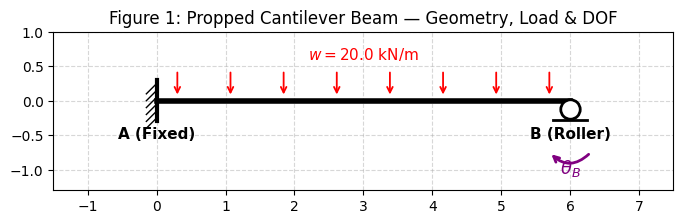

**② ⚠️ 自由度選取**（這一步選錯或漏掉，後面所有方程式都會建立在錯誤基礎上、整題全錯，是最需要覆核的一步）：

A端固定，轉角鎖死 $\theta_A=0$，不是未知量；B端是滾支承，可以自由轉動，所以 $\theta_B$ 是**唯一**的未知位移量。這是最基本的一次靜不定結構，是本課程的第一個Case——如果誤把 $\theta_A$ 也當成未知量列進方程式，或漏掉 $\theta_B$，後面的方程式全部會建立在錯的自由度上。


【步驟 2】寫出桿端彎矩方程式


**① 公式引用**（傾角變位法一般式，對任何桿件 i→j 都適用，跟結構種類無關）：

$$M_{ij} = \frac{2EI}{L}\left(2\theta_i + \theta_j - 3\psi\right) + FEM_{ij}$$

其中 $\theta_i,\theta_j$ 為兩端轉角，$\psi=\Delta/L$ 為側移角（無側移時 $\psi=0$），$FEM_{ij}$ 為固定端彎矩(依載重種類查表)。

**② 代入本題的邊界條件、跨長與載重**，得到每根桿件的具體算式：


【步驟 3】建立平衡方程式


**平衡方程式**（每條方程式對應哪個節點/桿件、哪一種平衡條件）：

- B端邊界條件（滾支承不傳彎矩） M_BA = 0


【步驟 4】求解聯立方程式 (未知位移量)


**位移求解結果：**


【步驟 5】計算真實桿端彎矩與反力


**最終桿端彎矩計算結果 (kN·m)：**

M_{AB} = 90.000 kN·m
M_{BA} = 0.000 kN·m

-> R_A (kN, 固定端反力) = 75.000
-> R_B (kN, 滾支承反力) = 45.000

【步驟 6】繪製剪力圖 (SFD)


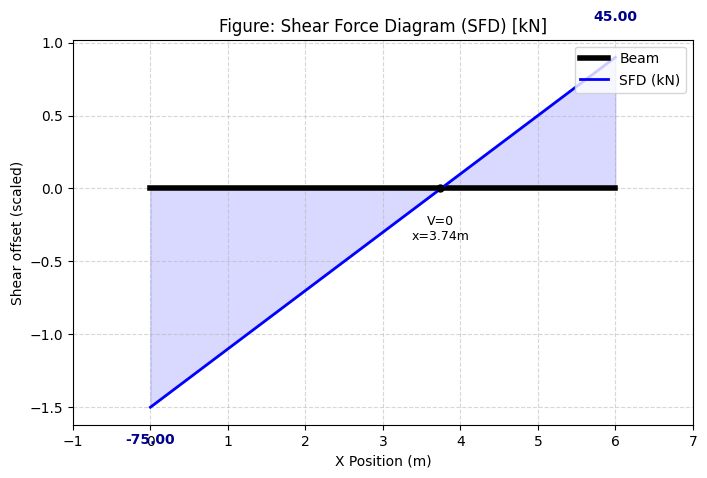


【步驟 7】繪製彎矩圖 (BMD)


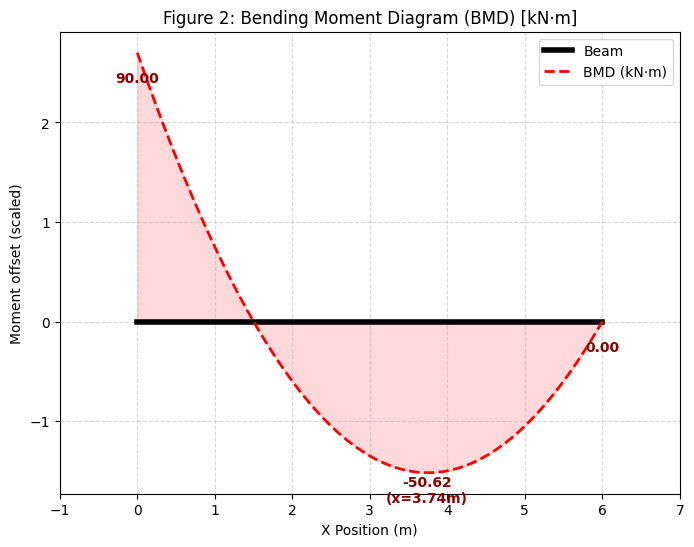

{'moments': {'M_{AB}': 90.0, 'M_{BA}': 0.0},
 'reactions': {'R_A (kN, 固定端反力)': 75.0, 'R_B (kN, 滾支承反力)': 45.0},
 'solution': {theta_B: 90.0/EI}}

In [3]:
problem = PropChedCantileverProblem(L=6.0, w=20.0)
SlopeDeflectionSolver(problem).solve_and_report()

## 2. anastruct 獨立建模驗證

A端反力: {'id': 1, 'Fx': np.float64(-7.347880794884118e-15), 'Fy': np.float64(-74.99999250000374), 'Tz': np.float64(-89.99995500002248), 'ux': np.float64(-0.0), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.0)}
B端反力: {'id': 2, 'Fx': np.float64(0.0), 'Fy': np.float64(-45.00000749999626), 'Tz': np.float64(0.0), 'ux': np.float64(2.2043642384652356e-22), 'uy': np.float64(0.0), 'phi_z': np.float64(-0.005999997000001495)}


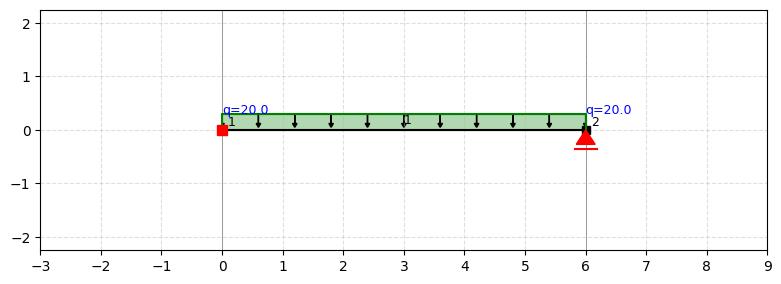

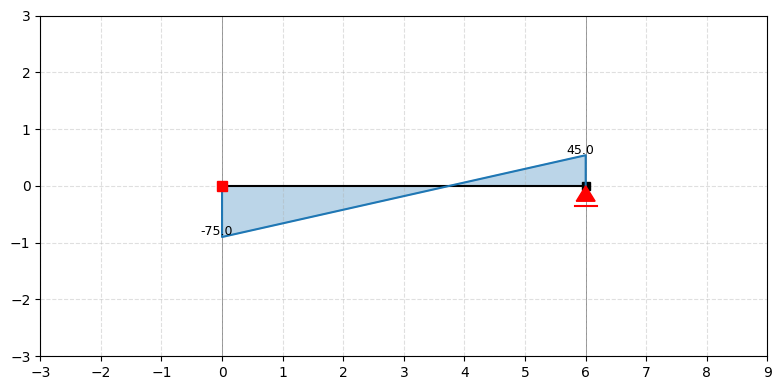

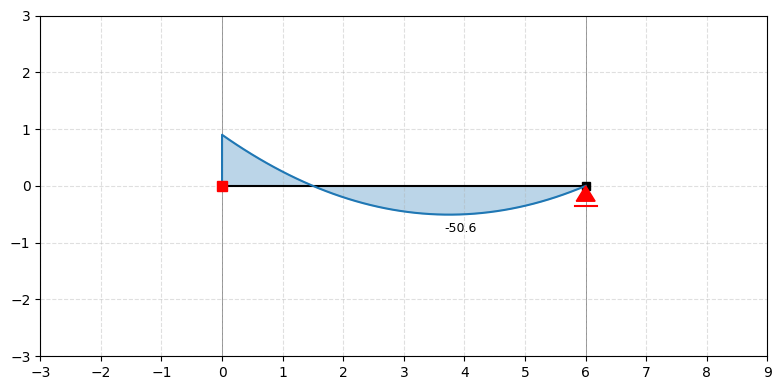

In [4]:
from anastruct import SystemElements
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

L, w = 6.0, 20.0
ss = SystemElements(EA=1e8, EI=15000.0)
ss.add_element(location=[[0, 0], [L, 0]])
ss.add_support_fixed(node_id=1)
ss.add_support_roll(node_id=2, direction='x')
ss.q_load(element_id=1, q=-w)
ss.solve()

print("A端反力:", ss.get_node_results_system(1))
print("B端反力:", ss.get_node_results_system(2))

def apply_grid(fig, supports):
    ax = fig.axes[0]
    ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
    ax.grid(True, linestyle='--', alpha=0.4)
    for x in supports:
        ax.axvline(x, color='gray', lw=0.6, zorder=0)
    return fig

fig_s = ss.show_structure(show=False, figsize=(8, 3))
apply_grid(fig_s, [0, L])
plt.show()

fig_v = ss.show_shear_force(show=False, figsize=(8, 4))
apply_grid(fig_v, [0, L])
plt.show()

fig_m = ss.show_bending_moment(show=False, figsize=(8, 4))
apply_grid(fig_m, [0, L])
plt.show()

## 3. 剪力交叉檢查

In [5]:
Mi, Mj = 90.0, 0.0
C1 = (Mj - Mi - 0.5*w*L**2) / L
V0_predict, VL_predict = C1, C1 + w*L
print(f"我們框架推算剪力: V(0)={V0_predict:.3f}  V(L)={VL_predict:.3f}")

el = ss.element_map[1]
print(f"anastruct 實際剪力: V(0)={el.shear_force[0]:.3f}  V(L)={el.shear_force[-1]:.3f}")

assert abs(V0_predict - el.shear_force[0]) < 0.01, "剪力對不上!"
assert abs(VL_predict - el.shear_force[-1]) < 0.01, "剪力對不上!"
print("\n剪力交叉檢查通過 ✓")

我們框架推算剪力: V(0)=-75.000  V(L)=45.000
anastruct 實際剪力: V(0)=-75.000  V(L)=45.000

剪力交叉檢查通過 ✓
